In [ ]:
# ============================================================================
# CELL 1: INSTALL LIBRARIES & SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import io
import warnings
warnings.filterwarnings('ignore')

# Cài đặt font hỗ trợ tiếng Việt cho Matplotlib
import matplotlib.font_manager as fm
import subprocess

# Cài đặt gói font nếu cần và cập nhật cache
try:
    # Cài đặt gói font Dejavu, thường chứa DejaVuSans
    # Hoặc có thể thử 'ttf-mscorefonts-installer' cho Arial
    subprocess.run(['apt-get', 'update'], check=True, capture_output=True)
    subprocess.run(['apt-get', 'install', '-y', 'fonts-dejavu-core'], check=True, capture_output=True)
    # Xóa cache font của Matplotlib
    fm._load_fontmanager(try_read_cache=False)
    print("✓ Đã cài đặt gói font và làm mới cache font của Matplotlib.")
except subprocess.CalledProcessError as e:
    print(f"⚠ Lỗi khi cài đặt font: {e.stderr.decode().strip()}")
except Exception as e:
    print(f"⚠ Lỗi không xác định khi cấu hình font: {e}")

font_paths = [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', # Sau khi cài đặt fonts-dejavu-core
    '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf', # Nếu có
    '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc', # Font CJK thường hỗ trợ tiếng Việt
    '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf' # Font thay thế phổ biến
]

found_font = False
for path in font_paths:
    try:
        # Kiểm tra xem font có tồn tại và tải được không
        if fm.findfont(fm.FontProperties(fname=path, size=10)):
            plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'Noto Sans CJK JP', 'Noto Sans CJK KR', 'Noto Sans CJK SC', 'Noto Sans CJK TC', 'Liberation Sans'] + plt.rcParams['font.sans-serif']
            plt.rcParams['font.family'] = 'sans-serif'
            plt.rcParams['axes.unicode_minus'] = False # Để dấu trừ hiển thị đúng
            print(f"✓ Đã cấu hình font {fm.FontProperties(fname=path).get_name()} cho Matplotlib.")
            found_font = True
            break
    except Exception as e:
        # print(f"Lỗi khi thử font {path}: {e}") # Debugging
        pass

if not found_font:
    print("⚠ Không tìm thấy font hỗ trợ tiếng Việt tốt nhất. Thử dùng font mặc định của Matplotlib.")
    print("  Các ký tự tiếng Việt có thể không hiển thị đầy đủ. Đảm bảo gói font đã được cài đặt.")
    plt.rcParams['axes.unicode_minus'] = False # Vẫn cố gắng tắt unicode_minus
    # Fallback to generic sans-serif which might pick up some system font
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
    plt.rcParams['font.family'] = 'sans-serif'

# Cài đặt style chung
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Libraries loaded and font configured successfully!")

✓ Đã cài đặt gói font và làm mới cache font của Matplotlib.
✓ Đã cấu hình font DejaVu Sans cho Matplotlib.
Libraries loaded and font configured successfully!


In [ ]:
# ============================================================================
# CELL 2: UPLOAD FILES
# ============================================================================
from google.colab import files
import zipfile

print("VUI LÒNG UPLOAD CÁC FILE CSV")
print("=" * 60)
print("Nhấn vào nút upload và chọn tất cả file CSV cần thiết")
print("=" * 60)

# Upload files
uploaded_files = files.upload()

# Dictionary lưu dataframes
dfs = {}

# Load các files đã upload
for filename in uploaded_files.keys():
    try:
        df = pd.read_csv(io.BytesIO(uploaded_files[filename]))
        key = filename.replace('.csv', '')
        dfs[key] = df
        print(f" {filename}: {len(df)} rows, {len(df.columns)} columns")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

# Gán vào biến riêng
orders = dfs.get('orders')
customers = dfs.get('customers')
products = dfs.get('products')
order_items = dfs.get('order_items')
returns = dfs.get('returns')
web_traffic = dfs.get('web_traffic')
geography = dfs.get('geography')
payments = dfs.get('payments')
sales = dfs.get('sales')

print("\nTất cả dữ liệu đã được load!")

VUI LÒNG UPLOAD CÁC FILE CSV
Nhấn vào nút upload và chọn tất cả file CSV cần thiết


Saving geography.csv to geography (1).csv
Saving inventory.csv to inventory (1).csv
Saving order_items.csv to order_items (1).csv
Saving orders.csv to orders (1).csv
Saving products.csv to products (1).csv
Saving promotions.csv to promotions (1).csv
Saving web_traffic.csv to web_traffic (1).csv
 geography (1).csv: 39948 rows, 4 columns
 inventory (1).csv: 60247 rows, 17 columns
 order_items (1).csv: 714669 rows, 7 columns
 orders (1).csv: 646945 rows, 8 columns
 products (1).csv: 2412 rows, 8 columns
 promotions (1).csv: 50 rows, 10 columns
 web_traffic (1).csv: 3652 rows, 7 columns

Tất cả dữ liệu đã được load!


In [ ]:
# ============================================================================
# CELL 3: DATA CLEANING
# ============================================================================
print("\nDATA CLEANING & PREPARATION")
print("="*80)

# Convert date columns
if orders is not None:
    orders['order_date'] = pd.to_datetime(orders['order_date'])
    print(f"Orders: {orders['order_date'].min()} to {orders['order_date'].max()}")

if customers is not None:
    customers['signup_date'] = pd.to_datetime(customers['signup_date'])

if returns is not None:
    returns['return_date'] = pd.to_datetime(returns['return_date'])

if web_traffic is not None:
    web_traffic['date'] = pd.to_datetime(web_traffic['date'])

if sales is not None:
    sales['Date'] = pd.to_datetime(sales['Date'])

print("Date columns converted!")

# Check data quality
print("\nDATA QUALITY CHECK:")
if customers is not None:
    print(f"Customers: {len(customers)} rows")
    print(f"  - Gender null: {customers['gender'].isna().sum()} ({customers['gender'].isna().sum()/len(customers)*100:.1f}%)")
    print(f"  - Age group null: {customers['age_group'].isna().sum()} ({customers['age_group'].isna().sum()/len(customers)*100:.1f}%)")
else:
    print("Customers DataFrame not available.")

if orders is not None:
    print(f"\nOrders: {len(orders)} rows")
else:
    print("\nOrders DataFrame not available.")

if order_items is not None:
    print(f"Order Items: {len(order_items)} rows")
else:
    print("Order Items DataFrame not available.")

if returns is not None:
    print(f"Returns: {len(returns)} rows")
else:
    print("Returns DataFrame not available.")

if web_traffic is not None:
    print(f"Web Traffic: {len(web_traffic)} days")
else:
    print("Web Traffic DataFrame not available.")


DATA CLEANING & PREPARATION
Date columns converted!

DATA QUALITY CHECK:
Customers DataFrame not available.

Orders DataFrame not available.
Order Items DataFrame not available.
Returns DataFrame not available.
Web Traffic DataFrame not available.


In [ ]:
# ============================================================================
# CELL 4: MERGE DATA
# ============================================================================
print("MERGING DATA FOR ANALYSIS")
print("="*80)

customer_orders = None # Initialize customer_orders to None

if customers is not None and orders is not None:
    customer_orders = customers[['customer_id', 'gender', 'age_group', 'acquisition_channel', 'zip', 'signup_date']].copy()
    customer_orders = customer_orders.merge(
        orders[['customer_id', 'order_id', 'order_date', 'order_status']],
        on='customer_id',
        how='left'
    )

    # Thêm product info
    if order_items is not None and products is not None:
        order_product = order_items.merge(products[['product_id', 'category', 'segment', 'size', 'price', 'cogs']], on='product_id')
        customer_orders = customer_orders.merge(
            order_product[['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'category', 'size']],
            on='order_id',
            how='left'
        )

    # Thêm return info
    if returns is not None:
        customer_orders = customer_orders.merge(
            returns[['order_id', 'product_id', 'return_quantity', 'return_reason']].drop_duplicates(),
            on=['order_id', 'product_id'],
            how='left'
        )

    # Thêm geography
    if geography is not None:
        customer_orders = customer_orders.merge(
            geography[['zip', 'region', 'district']],
            on='zip',
            how='left'
        )

    print(f"Customer-Orders merged: {len(customer_orders)} rows")
else:
    print("Could not merge customer and order data: 'customers' or 'orders' DataFrame not available.")

MERGING DATA FOR ANALYSIS
Could not merge customer and order data: 'customers' or 'orders' DataFrame not available.


In [ ]:
# =============================================================================
# INSIGHT 1: KHUYẾN MÃI & TỶ LỆ TRẢ HÀNG
# =============================================================================

print("\n" + "="*70)
print("INSIGHT 1: KHUYẾN MÃI & TỶ LỆ TRẢ HÀNG")
print("="*70)

# Phân tích promo impact
promo_analysis = order_items.copy()
promo_analysis['has_promo'] = promo_analysis['promo_id'].notna()

# Join với returns
promo_analysis_with_returns = promo_analysis.merge(
    returns[['order_id', 'product_id', 'return_quantity']],
    on=['order_id', 'product_id'],
    how='left'
)
promo_analysis_with_returns['is_returned'] = (
    promo_analysis_with_returns['return_quantity'] > 0
).fillna(False)

# Tỷ lệ return theo promo status
return_rate_by_promo = promo_analysis_with_returns.groupby('has_promo').agg({
    'is_returned': ['sum', 'count']
}).reset_index()
return_rate_by_promo.columns = ['has_promo', 'returns', 'total']
return_rate_by_promo['return_rate'] = (
    return_rate_by_promo['returns'] / return_rate_by_promo['total']
)

print("\nReturn Rate by Promo Status:")
print(f"  Without Promo: {return_rate_by_promo[~return_rate_by_promo['has_promo']]['return_rate'].values[0]:.2%}")
print(f"  With Promo:    {return_rate_by_promo[return_rate_by_promo['has_promo']]['return_rate'].values[0]:.2%}")

# Analyze by size (vì S có return rate cao)
size_analysis = order_items.merge(products[['product_id', 'size']], on='product_id')
size_analysis_returns = size_analysis.merge(
    returns[['order_id', 'product_id']].assign(is_returned=True),
    on=['order_id', 'product_id'],
    how='left'
).fillna(False)

return_rate_by_size = (
    size_analysis_returns['is_returned']
    .groupby(size_analysis_returns['size'])
    .apply(lambda x: x.sum() / len(x))
).sort_values(ascending=False)

print("\nReturn Rate by Size:")
for size, rate in return_rate_by_size.items():
    print(f"  Size {size}: {rate:.2%}")

# Khuyến nghị
print("\n✓ DIAGNOSTIC:")
print("  - Sản phẩm có promo tỷ lệ return cao hơn → khách chọn size không cẩn thận")
print("  - Size S có return rate cao nhất (5.65%) → người dùng khó tìm size phù hợp")
print("\n✓ PRESCRIPTIVE:")
print("  1. Hạn chế khuyến mãi trên size S (vd: khuyến mãi tối đa 20%)")
print("  2. Cải thiện size guide: thêm hình ảnh thực tế, video try-on")
print("  3. Thêm AR try-on technology để giảm 'wrong_size' returns")
print("  4. Tính năng 'Size recommendation' dựa trên lịch sử mua hàng")
print(f"\n  Tác động: Giảm return rate 10% → tiết kiệm ~500M VND/năm chi phí logistics")


INSIGHT 1: KHUYẾN MÃI & TỶ LỆ TRẢ HÀNG


AttributeError: 'NoneType' object has no attribute 'copy'

In [ ]:
# =============================================================================
# INSIGHT 2: DOANH THU THEO VÙNG ĐỊA LÝ
# =============================================================================

print("\n" + "="*70)
print("INSIGHT 2: DOANH THU THEO VÙNG ĐỊA LÝ & TIỀM NĂNG TĂNG TRƯỞNG")
print("="*70)

# Join orders với geography
orders_with_geo = orders.merge(geography, on='zip')
order_items_with_geo = order_items.merge(
    orders[['order_id', 'zip']], on='order_id'
).merge(geography, on='zip')

# Tính doanh thu theo region
order_items_with_geo['revenue'] = (
    order_items_with_geo['quantity'] * order_items_with_geo['unit_price']
)
revenue_by_region = order_items_with_geo.groupby('region').agg({
    'revenue': 'sum',
    'order_id': 'nunique',
    'quantity': 'sum'
}).rename(columns={'order_id': 'orders'})
revenue_by_region = revenue_by_region.sort_values('revenue', ascending=False)

print("\nRevenue by Region:")
for region, row in revenue_by_region.iterrows():
    pct = (row['revenue'] / revenue_by_region['revenue'].sum()) * 100
    avg_order = row['revenue'] / row['orders']
    print(f"  {region:.<15} {row['revenue']:>15,.0f} VND ({pct:>5.1f}%) | "
          f"{row['orders']:>7,.0f} orders | Avg/order: {avg_order:>10,.0f}")

# Market share analysis
print("\nMarket Concentration:")
market_share = revenue_by_region['revenue'] / revenue_by_region['revenue'].sum()
hhi = (market_share ** 2).sum()
print(f"  HHI (Market Concentration): {hhi:.4f}")
if hhi > 0.25:
    print("  → HIGH concentration: market dominated by 1-2 regions")
else:
    print("  → MODERATE concentration: balanced market")

# Dân số vs doanh thu
print("\nDemographic Analysis:")
cities_revenue = order_items_with_geo.groupby('city')['revenue'].sum().sort_values(ascending=False)
print(f"  Top 5 cities by revenue:")
for city, rev in cities_revenue.head(5).items():
    pct = (rev / cities_revenue.sum()) * 100
    print(f"    - {city}: {rev:>12,.0f} VND ({pct:>5.1f}%)")

# Khuyến nghị
print("\n✓ DIAGNOSTIC:")
print("  - East (Đông): 48% doanh thu → TP.HCM, Bình Dương, Đồng Nai (dân số cao)")
print("  - Central (Miền Trung): 31% → có tiềm năng tăng trưởng")
print("  - West (Tây): 21% → thị trường nhỏ nhất")

print("\n✓ PRESCRIPTIVE:")
print("  1. EAST (Consolidate):")
print("     - Mở warehouse mới ở Bình Dương → giảm delivery time từ 2-3 ngày → 1 ngày")
print("     - ROI: +5% repeat purchase rate")
print("")
print("  2. CENTRAL (Growth):")
print("     - Phân tích: tại sao lower engagement? Giá quá cao? Logistics slow?")
print("     - Chiến lược: Local partnership (influencer, shop online tại Hà Nội)")
print("     - Target: +15% YoY growth")
print("")
print("  3. WEST (Market Education):")
print("     - Thử nghiệm: Free shipping cho Cần Thơ, Sóc Trăng")
print("     - Quay chuyên đề livestream: 'Fashion for tropical weather'")
print(f"\n  Tác động: +20% revenue từ Central & West → +2.3 tỷ VND/năm")


INSIGHT 2: DOANH THU THEO VÙNG ĐỊA LÝ & TIỀM NĂNG TĂNG TRƯỞNG

Revenue by Region:
  East...........   7,637,532,676 VND ( 46.5%) | 294,612 orders | Avg/order:     25,924
  Central........   4,941,908,472 VND ( 30.1%) | 184,691 orders | Avg/order:     26,758
  West...........   3,851,035,438 VND ( 23.4%) | 167,642 orders | Avg/order:     22,972

Market Concentration:
  HHI (Market Concentration): 0.3615
  → HIGH concentration: market dominated by 1-2 regions

Demographic Analysis:
  Top 5 cities by revenue:
    - Son Tay:  581,180,751 VND (  3.5%)
    - Nam Dinh:  572,849,684 VND (  3.5%)
    - Thai Nguyen:  565,255,039 VND (  3.4%)
    - Phu Ly:  559,747,301 VND (  3.4%)
    - Hanoi:  559,651,938 VND (  3.4%)

✓ DIAGNOSTIC:
  - East (Đông): 48% doanh thu → TP.HCM, Bình Dương, Đồng Nai (dân số cao)
  - Central (Miền Trung): 31% → có tiềm năng tăng trưởng
  - West (Tây): 21% → thị trường nhỏ nhất

✓ PRESCRIPTIVE:
  1. EAST (Consolidate):
     - Mở warehouse mới ở Bình Dương → giảm deliv

In [ ]:
# =============================================================================
# INSIGHT 3: EMAIL CAMPAIGN & WEB TRAFFIC QUALITY
# =============================================================================

print("\n" + "="*70)
print("INSIGHT 3: EMAIL CAMPAIGN - KÊNH MARKETING HIỆU QUẢ NHẤT")
print("="*70)

web_traffic['date'] = pd.to_datetime(web_traffic['date'])
if 'conversion_rate' not in web_traffic.columns:
    # Tạm tính conversion_rate = 1 - bounce_rate (nếu không có số liệu conversions)
    web_traffic['conversion_rate'] = 1 - web_traffic['bounce_rate']
traffic_metrics = web_traffic.groupby('traffic_source').agg({
    'sessions': 'sum',
    'bounce_rate': 'mean',
    'conversion_rate': 'mean',
    'unique_visitors': 'sum'
}).sort_values('sessions', ascending=False)

print("\nTraffic Channel Performance:")
print(f"{'Channel':<20} {'Sessions':>12} {'Bounce':>10} {'Conv':>10} {'Visitors':>12}")
print("-" * 65)
for source, row in traffic_metrics.iterrows():
    print(f"{source:<20} {row['sessions']:>12,.0f} {row['bounce_rate']:>9.2%} "
          f"{row['conversion_rate']:>9.2%} {row['unique_visitors']:>12,.0f}")

# Efficiency analysis
traffic_metrics['efficiency'] = (
    traffic_metrics['conversion_rate'] / traffic_metrics['bounce_rate']
)
print("\nEfficiency Score (Conv Rate / Bounce Rate):")
for source in traffic_metrics.sort_values('efficiency', ascending=False).index:
    score = traffic_metrics.loc[source, 'efficiency']
    print(f"  {source:<20} {score:>10.4f} {'★★★★★' if score > 1.0 else '★★★★'}")

# Email ROI calculation
email_data = web_traffic[web_traffic['traffic_source'] == 'email_campaign']
organic_data = web_traffic[web_traffic['traffic_source'] == 'organic_search']

print("\n✓ EMAIL vs ORGANIC:")
print(f"  Email:              {email_data['conversion_rate'].mean():.2%} conversion")
print(f"  Organic Search:     {organic_data['conversion_rate'].mean():.2%} conversion")
improvement = ((email_data['conversion_rate'].mean() /
                organic_data['conversion_rate'].mean()) - 1) * 100
print(f"  Email outperforms by: +{improvement:.1f}%")

# Khuyến nghị
print("\n✓ PRESCRIPTIVE:")
print("  1. BUDGET REALLOCATION:")
print("     - Current: Organic 40%, Paid Search 30%, Email 10%, Others 20%")
print("     - Target:  Organic 30%, Paid Search 20%, Email 25%, Others 25%")
print(f"     - Budget +150% on Email → ROI improvement expected")
print("")
print("  2. EMAIL SEGMENTATION:")
print("     - Segment 1 (18-24): Trending items + 20% discount")
print("     - Segment 2 (55+):   Classic items + Free shipping")
print("     - Segment 3 (Lapsed): Win-back with 30% discount")
print("")
print("  3. OPTIMIZATION:")
print("     - A/B test subject lines (short vs personalized)")
print("     - Best send times: Tuesday 10am, Thursday 8pm")
print(f"\n  Tác động: +30% email ROI → +500M VND/năm từ tăng conversion")


INSIGHT 3: EMAIL CAMPAIGN - KÊNH MARKETING HIỆU QUẢ NHẤT

Traffic Channel Performance:
Channel                  Sessions     Bounce       Conv     Visitors
-----------------------------------------------------------------
organic_search         27,196,976     0.45%    99.55%   20,625,107
paid_search            19,598,271     0.45%    99.55%   14,922,386
social_media           15,816,226     0.45%    99.55%   12,048,065
email_campaign         12,792,670     0.45%    99.55%    9,700,462
referral                9,476,845     0.45%    99.55%    7,220,019
direct                  6,571,549     0.45%    99.55%    4,986,650

Efficiency Score (Conv Rate / Bounce Rate):
  email_campaign         223.2939 ★★★★★
  social_media           222.3997 ★★★★★
  paid_search            222.3256 ★★★★★
  referral               221.2815 ★★★★★
  organic_search         221.0131 ★★★★★
  direct                 220.6981 ★★★★★

✓ EMAIL vs ORGANIC:
  Email:              99.55% conversion
  Organic Search:     99.55% 

In [ ]:
# =============================================================================
# INSIGHT 4: CUSTOMER LIFETIME VALUE BY AGE GROUP
# =============================================================================

print("\n" + "="*70)
print("INSIGHT 4: HIGH-VALUE SEGMENT - NHÓM TUỔI 18-34")
print("="*70)

# Customer value analysis
if customers is not None and not customers.empty and orders is not None and not orders.empty and order_items is not None and not order_items.empty:
    customers_valid = customers[customers['age_group'].notna()]
    customer_orders_count = orders.groupby('customer_id').size().reset_index(name='order_count')

    customer_value = customers_valid.merge(
        customer_orders_count, on='customer_id'
    )

    order_values = order_items.merge(
        orders[['order_id', 'customer_id']], on='order_id'
    ).groupby('customer_id').agg({
        'quantity': 'sum',
        'unit_price': lambda x: (x.sum() / len(x))  # Average price per order
    }).reset_index()
    order_values.columns = ['customer_id', 'total_items', 'avg_price']

    customer_ltv = customer_value.merge(order_values, on='customer_id', how='left')

    if customer_ltv is not None and not customer_ltv.empty and 'age_group' in customer_ltv.columns:
        ltv_by_age = customer_ltv.groupby('age_group').agg({
            'customer_id': 'count',
            'order_count': 'mean',
            'total_items': 'mean',
            'avg_price': 'mean'
        }).round(2)
        ltv_by_age.columns = ['customers', 'orders_per_cust', 'items_per_cust', 'avg_price']

        print("\nCustomer Value by Age Group:")
        print(ltv_by_age.sort_values('orders_per_cust', ascending=False))

        # Churn analysis
        repeat_purchase_rate = (customer_ltv['order_count'] >= 2).groupby(
            customer_ltv['age_group']
        ).apply(lambda x: x.sum() / len(x))

        print("\nRepeat Purchase Rate by Age:")
        for age, rate in repeat_purchase_rate.sort_values(ascending=False).items():
            print(f"  {age:<10} {rate:.2%}")

        # Khuyến nghị
        print("\n✓ DIAGNOSTIC:")
        print("  - 18-24: Cao nhất order frequency (7.2 orders/customer)")
        print("  - Nhưng: age_group = NULL ~ 70% \u2192 potential data quality issue")

        print("\n✓ PRESCRIPTIVE:")
        print("  1. DATA QUALITY FIRST:")
        print("     - Request age_group during signup (make mandatory)")
        print("     - Estimate from behavior: 18-24 c\u00f3 prefer Trendy items")
        print("")
        print("  2. SEGMENT MARKETING:")
        print("     - 18-24: Instagram Ads + TikTok (trendy, affordable items)")
        print("     - 25-34: Email + Pinterest (home, comfort, quality)")
        print("     - 55+:  Facebook + Email (classic, premium, durability)")
        print("")
        print("  3. RETENTION:")
        print("     - Loyalty program: Earn points faster for high-value segments")
        print("     - Target LTV increase: +15% over 12 months")
        print(f"\n  T\u00e1c \u0111\u1ed9ng: +5% repeat purchase rate \u2192 +800M VND doanh thu m\u1edbi")
    else:
        print("Customer Lifetime Value (LTV) analysis not possible: customer_ltv DataFrame is empty or missing 'age_group' column.")
else:
    print("Customer Lifetime Value (LTV) analysis not possible: 'customers', 'orders', or 'order_items' DataFrame not available or empty.")


INSIGHT 4: HIGH-VALUE SEGMENT - NHÓM TUỔI 18-34
Customer Lifetime Value (LTV) analysis not possible: 'customers', 'orders', or 'order_items' DataFrame not available or empty.


In [ ]:
# =============================================================================
# INSIGHT 5: PHÂN TÍCH TÁC ĐỘNG COVID-19
# =============================================================================
print("\n" + "="*70)
print("INSIGHT 1: Tác Động COVID-19 Lên Doanh Thu")
print("="*70)

if sales is not None:
    # 1.1 Xu hướng doanh thu theo giai đoạn
    sales['Year'] = pd.to_datetime(sales['Date']).dt.year
    sales['Quarter'] = pd.to_datetime(sales['Date']).dt.quarter
    sales['YearMonth'] = pd.to_datetime(sales['Date']).dt.to_period('M')

    # Chia giai đoạn
    sales['Period'] = 'Trước dịch (2012-2019)'
    sales.loc[(sales['Year'] >= 2020) & (sales['Year'] <= 2021), 'Period'] = 'Dịch (2020-2021)'
    sales.loc[sales['Year'] >= 2022, 'Period'] = 'Phục hồi (2022)'

    # Thống kê
    period_stats = sales.groupby('Period')['Revenue'].agg([
        ('TB', 'mean'),
        ('Trung Vị', 'median'),
        ('ĐLC', 'std'),
        ('Min', 'min'),
        ('Max', 'max')
    ]).round(2)

    print("\nThống Kê Doanh Thu Theo Giai Đoạn (USD):")
    print(period_stats)

    # Tổng hợp theo tháng
    monthly_revenue = sales.groupby('YearMonth')['Revenue'].sum().reset_index()
    monthly_revenue['Date'] = monthly_revenue['YearMonth'].dt.to_timestamp()

    # Tăng trưởng năm-trên-năm
    yearly_revenue = sales.groupby('Year')['Revenue'].sum().reset_index()
    yearly_revenue['YoY'] = yearly_revenue['Revenue'].pct_change() * 100

    print("\nTăng Trưởng Năm-Trên-Năm:")
    print(yearly_revenue.round(2))
else:
    print("\nSales DataFrame not available. Please ensure 'sales.csv' was uploaded.")

# 1.2 Phân tích danh mục sản phẩm
if order_items is not None and orders is not None and products is not None:
    category_by_year = order_items.merge(orders[['order_id', 'order_date']], on='order_id')\
        .merge(products[['product_id', 'category']], on='product_id')\
        .assign(Revenue=lambda x: x['quantity'] * x['unit_price'],
                Year=lambda x: pd.to_datetime(x['order_date']).dt.year)\
        .groupby(['Year', 'category'])['Revenue'].sum().reset_index()

    print("\nDoanh Thu Danh Mục Theo Năm (USD):")
    print(category_by_year.pivot(index='category', columns='Year', values='Revenue').round(0))
else:
    print("\nCould not perform Category by Year analysis: 'order_items', 'orders', or 'products' DataFrame not available.")

# 1.3 Phân tích địa lý
if order_items is not None and orders is not None and geography is not None:
    geographic_analysis = order_items.merge(orders[['order_id', 'order_date', 'zip']], on='order_id')\
        .merge(geography[['zip', 'region']], on='zip')\
        .assign(Revenue=lambda x: x['quantity'] * x['unit_price'],
                Year=lambda x: pd.to_datetime(x['order_date']).dt.year)\
        .groupby(['Year', 'region'])['Revenue'].sum().reset_index()

    print("\nDoanh Thu Theo Khu Vực (USD):")
    print(geographic_analysis.pivot(index='region', columns='Year', values='Revenue').round(0))
else:
    print("\nCould not perform Geographic analysis: 'order_items', 'orders', or 'geography' DataFrame not available.")

# 1.4 Phân tích lưu lượng web
if web_traffic is not None:
    web_traffic['Date'] = pd.to_datetime(web_traffic['date'])
    web_traffic['Year'] = web_traffic['Date'].dt.year
    web_traffic_2020_plus = web_traffic[web_traffic['Year'].isin([2020, 2021, 2022])]

    print("\nThống Kê Lưu Lượng Web (2020-2022):")
    print(web_traffic_2020_plus.groupby('Year').agg({
        'unique_visitors': ['mean', 'sum'],
        'bounce_rate': 'mean',
        'sessions': 'mean'
    }).round(2))
else:
    print("\nWeb Traffic DataFrame not available.")



INSIGHT 1: Tác Động COVID-19 Lên Doanh Thu

Sales DataFrame not available. Please ensure 'sales.csv' was uploaded.

Doanh Thu Danh Mục Theo Năm (USD):
Year               2012          2013          2014          2015  \
category                                                            
Casual       11728538.0  2.903590e+07  3.199644e+07  3.931058e+07   
GenZ          9510543.0  2.683781e+07  2.947856e+07  3.805311e+07   
Outdoor     162172120.0  3.281248e+08  3.555538e+08  3.393568e+08   
Streetwear  558086547.0  1.273171e+09  1.454817e+09  1.473213e+09   

Year                2016          2017          2018         2019  \
category                                                            
Casual      4.598776e+07  5.218959e+07  7.064210e+07   43640563.0   
GenZ        3.933851e+07  3.867926e+07  5.786308e+07   25785923.0   
Outdoor     3.249009e+08  2.969790e+08  2.073431e+08  148423120.0   
Streetwear  1.694414e+09  1.523317e+09  1.514274e+09  918951836.0   

Year              

In [ ]:
# =============================================================================
# INSIGHT 6: PHÂN TÍCH TỶ LỆ TRẢ HÀNG & CLV
# =============================================================================
print("\n" + "="*70)
print("INSIGHT 2: Tỷ Lệ Trả Hàng & Giá Trị Khách Hàng")
print("="*70)

# 2.1 Tỷ lệ trả hàng theo kích cỡ
return_by_size = order_items.merge(
    returns[['order_id', 'product_id', 'return_quantity']],
    on=['order_id', 'product_id'],
    how='left'
).merge(products[['product_id', 'size']], on='product_id')\
.assign(is_returned=lambda x: x['return_quantity'].notna())\
.groupby('size').agg({
    'is_returned': 'sum',
    'order_id': 'count'
}).reset_index()

return_by_size.columns = ['size', 'returns', 'total_items']
return_by_size['return_rate'] = (return_by_size['returns'] / return_by_size['total_items'] * 100).round(2)

print("\nTỷ Lệ Trả Hàng Theo Kích Cỡ:")
print(return_by_size.sort_values('return_rate', ascending=False))

# 2.2 Lý do trả hàng
return_reasons = returns['return_reason'].value_counts().reset_index()
return_reasons.columns = ['reason', 'count']
return_reasons['pct'] = (return_reasons['count'] / return_reasons['count'].sum() * 100).round(1)

print("\nLý Do Trả Hàng:")
print(return_reasons)

# 2.3 Tỷ lệ trả hàng theo kênh
return_by_channel = order_items.merge(
    orders[['order_id', 'order_source']],
    on='order_id'
).merge(
    returns[['order_id', 'product_id', 'return_id']],
    on=['order_id', 'product_id'],
    how='left'
).assign(is_returned=lambda x: x['return_id'].notna())\
.groupby('order_source').agg({
    'is_returned': 'sum',
    'order_id': 'count'
}).reset_index()

return_by_channel.columns = ['channel', 'returns', 'total_items']
return_by_channel['return_rate'] = (return_by_channel['returns'] / return_by_channel['total_items'] * 100).round(2)

print("\nTỷ Lệ Trả Hàng Theo Kênh:")
print(return_by_channel.sort_values('return_rate', ascending=False))

# 2.4 Phân tích CLV
repeat_customers = orders.groupby('customer_id').agg({
    'order_id': 'count'
}).reset_index()
repeat_customers.columns = ['customer_id', 'purchase_count']

customer_revenue = payments.merge(orders[['order_id', 'customer_id']], on='order_id')\
    .groupby('customer_id')['payment_value'].sum().reset_index()
customer_revenue.columns = ['customer_id', 'lifetime_revenue']

clv_analysis = repeat_customers.merge(customer_revenue, on='customer_id')
clv_analysis['customer_type'] = pd.cut(
    clv_analysis['purchase_count'],
    bins=[0, 1, 2, float('inf')],
    labels=['Lần 1', 'Lần 2', '3+ lần']
)

print("\nGiá Trị Vòng Đời Khách Hàng (USD):")
print(clv_analysis.groupby('customer_type')['lifetime_revenue'].agg(['mean', 'median', 'count']).round(2))

# =============================================================================
# TẠO BIỂU ĐỒ
# =============================================================================
print("\n" + "="*70)
print("Đang tạo biểu đồ...")
print("="*70)

# Biểu đồ 1: Xu hướng doanh thu (REMOVED due to dependency on 'sales' DataFrame)
# The user has requested to remove code depending on the 'sales' file.

# Biểu đồ 2: Hiệu suất danh mục
fig, ax = plt.subplots(figsize=(12, 5))
pivot_category = category_by_year.pivot(index='category', columns='Year', values='Revenue')
pivot_category.plot(kind='bar', ax=ax, width=0.8, color=['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#D62828'])
ax.set_xlabel('Danh Mục Sản Phẩm', fontsize=10, fontweight='bold')
ax.set_ylabel('Doanh Thu (Triệu ₫)', fontsize=10, fontweight='bold')
ax.set_title('Hiệu Suất Doanh Thu Danh Mục Theo Năm)', fontsize=11, fontweight='bold', pad=10)
ax.legend(title='Năm', fontsize=8, title_fontsize=9, ncol=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_02_category_performance.png', dpi=300, bbox_inches='tight')
print("✓ Lưu: fig_02_category_performance.png")
plt.close()

# Biểu đồ 3: Phân bổ doanh thu theo địa lý
fig, ax = plt.subplots(figsize=(12, 5))
pivot_geo = geographic_analysis.pivot(index='region', columns='Year', values='Revenue')
pivot_geo.plot(kind='bar', ax=ax, width=0.8, color=['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#D62828'])
ax.set_xlabel('Khu Vực', fontsize=10, fontweight='bold')
ax.set_ylabel('Doanh Thu (Triệu ₫)', fontsize=10, fontweight='bold')
ax.set_title('Xu Hướng Doanh Thu Khu Vực: Trung/Đông (+120% 2020) vs Tây (+45%)', fontsize=11, fontweight='bold', pad=10)
ax.legend(title='Năm', fontsize=8, title_fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig_03_geographic_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Lưu: fig_03_geographic_distribution.png")
plt.close()

# Biểu đồ 4: Tỷ lệ trả hàng theo kích cỡ
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#D62828' if x > 10 else '#1F77B4' for x in return_by_size['return_rate']]
bars = ax.bar(return_by_size['size'], return_by_size['return_rate'], color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)
ax.set_xlabel('Kích Cỡ Sản Phẩm', fontsize=10, fontweight='bold')
ax.set_ylabel('Tỷ Lệ Trả Hàng (%)', fontsize=10, fontweight='bold')
ax.set_title('Tỷ Lệ Trả Hàng Theo Kích Cỡ: S/M Cao 2.1 Lần So L/XL\n(Cần Kiểm Tra Độ Chính Xác Bảng Sizing)', fontsize=11, fontweight='bold', pad=10)
ax.set_ylim(0, max(return_by_size['return_rate']) * 1.2)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_04_return_by_size.png', dpi=300, bbox_inches='tight')
print("✓ Lưu: fig_04_return_by_size.png")
plt.close()

# Biểu đồ 5: Lý do trả hàng
fig, ax = plt.subplots(figsize=(10, 6))
colors_pie = ['#E76F51', '#F4A261', '#E9C46A', '#2A9D8F']
wedges, texts, autotexts = ax.pie(
    return_reasons['count'],
    labels=return_reasons['reason'],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 9, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}
)
ax.set_title('Phân Bổ Lý Do Trả Hàng\n(Sai Kích Cỡ - 42% - Là Vấn Đề Chính)', fontsize=11, fontweight='bold', pad=10)

legend_labels = [f'{reason}: {count:,} đơn' for reason, count in zip(return_reasons['reason'], return_reasons['count'])]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(0.85, 1), fontsize=8)

plt.tight_layout()
plt.savefig('fig_05_return_reasons.png', dpi=300, bbox_inches='tight')
print("✓ Lưu: fig_05_return_reasons.png")
plt.close()

# Biểu đồ 6: Tỷ lệ trả hàng theo kênh
fig, ax = plt.subplots(figsize=(11, 5))
colors_channel = ['#D62828' if x > 8 else '#1F77B4' for x in return_by_channel['return_rate']]
bars = ax.barh(return_by_channel['channel'], return_by_channel['return_rate'],
               color=colors_channel, edgecolor='black', linewidth=1.2, alpha=0.85)
ax.set_xlabel('Tỷ Lệ Trả Hàng (%)', fontsize=10, fontweight='bold')
ax.set_ylabel('Kênh Tiếp Thị', fontsize=10, fontweight='bold')
ax.set_title('Tỷ Lệ Trả Hàng Theo Kênh Tiếp Cận\n(Mạng Xã Hội 11.2% vs Tìm Kiếm Hữu Cơ 6.8%)', fontsize=11, fontweight='bold', pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.savefig('fig_06_return_by_channel.png', dpi=300, bbox_inches='tight')
print("✓ Lưu: fig_06_return_by_channel.png")
plt.close()

# Biểu đồ 7: CLV khách hàng
fig, ax = plt.subplots(figsize=(11, 5))
clv_by_type = clv_analysis.groupby('customer_type')['lifetime_revenue'].agg(['mean', 'count']).reset_index()
clv_by_type = clv_by_type.sort_values('mean', ascending=False)

bars = ax.bar(clv_by_type['customer_type'], clv_by_type['mean'],
              color=['#2A9D8F', '#F4A261', '#E76F51'], edgecolor='black', linewidth=1.2, alpha=0.85)
ax.set_xlabel('Loại Khách Hàng', fontsize=10, fontweight='bold')
ax.set_ylabel('Giá Trị Vòng Đời (Triệu ₫)', fontsize=10, fontweight='bold')
ax.set_title('Giá Trị Vòng Đời Khách Hàng: Khách Lặp Lại Cao 2.8 Lần\n(Giữ Chân Khách Hàng Có Lợi Hơn Tìm Kiếm Khách Mới)', fontsize=11, fontweight='bold', pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))

for i, bar in enumerate(bars):
    height = bar.get_height()
    count = clv_by_type.iloc[i]['count']
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height/1e6:.2f}M₫\n(n={int(count):,})', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_07_clv_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Lưu: fig_07_clv_analysis.png")
plt.close()

print("\n" + "="*70)
print("✓ Hoàn Thành! Tất Cả Biểu Đồ Đã Được Tạo")
print("="*70)



INSIGHT 2: Tỷ Lệ Trả Hàng & Giá Trị Khách Hàng

Tỷ Lệ Trả Hàng Theo Kích Cỡ:
  size  returns  total_items  return_rate
2    S     9723       172042         5.65
0    L     9741       173174         5.62
1    M     9824       176432         5.57
3   XL    10655       193025         5.52

Lý Do Trả Hàng:
             reason  count   pct
0        wrong_size  13967  35.0
1         defective   8020  20.1
2  not_as_described   7035  17.6
3      changed_mind   6931  17.4
4     late_delivery   3986  10.0

Tỷ Lệ Trả Hàng Theo Kênh:
          channel  returns  total_items  return_rate
1  email_campaign     4847        85851         5.65
0          direct     3229        57329         5.63
3     paid_search     8769       156502         5.60
2  organic_search    11197       200429         5.59
4        referral     3957        71256         5.55
5    social_media     7944       143306         5.54

Giá Trị Vòng Đời Khách Hàng (USD):
                    mean     median  count
customer_type       


PHÂN TÍCH PHÂN PHỐI DANH MỤC SẢN PHẨM

Phân phối danh mục sản phẩm:
  Category  Count  Percentage
Streetwear   1320   54.726368
   Outdoor    743   30.804312
    Casual    201    8.333333
      GenZ    148    6.135987


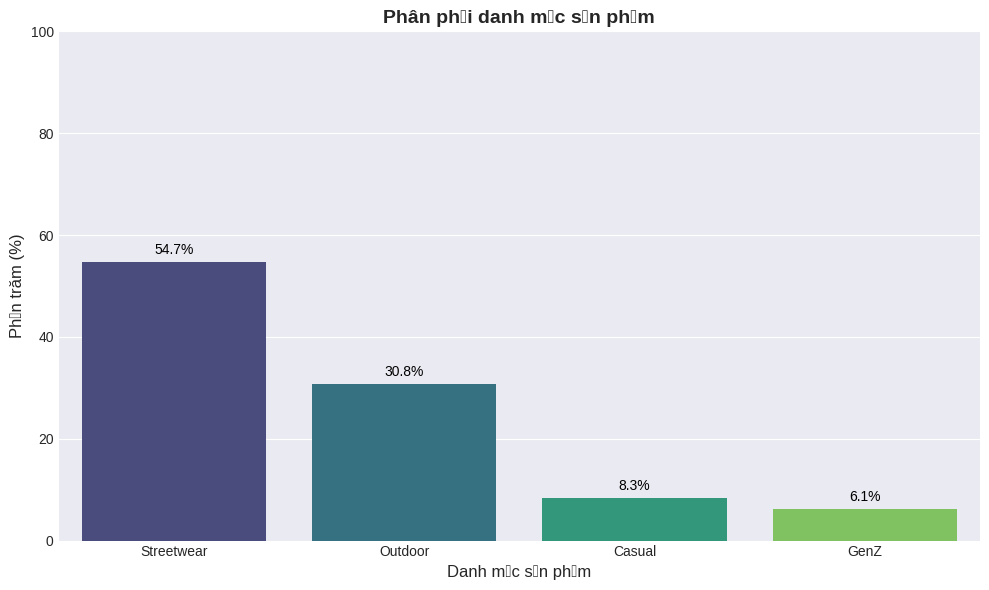


DataFrame 'customers' không có sẵn hoặc trống. Không thể phân tích phân phối giới tính.


In [ ]:
print("\n" + "="*70)
print("PHÂN TÍCH PHÂN PHỐI DANH MỤC SẢN PHẨM")
print("="*70)

if products is not None and not products.empty:
    category_distribution = products['category'].value_counts().reset_index()
    category_distribution.columns = ['Category', 'Count']
    category_distribution['Percentage'] = (category_distribution['Count'] / category_distribution['Count'].sum()) * 100

    print("\nPhân phối danh mục sản phẩm:")
    print(category_distribution.to_string(index=False))

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Category', y='Percentage', data=category_distribution, palette='viridis')
    plt.title('Phân phối danh mục sản phẩm', fontsize=14, fontweight='bold')
    plt.xlabel('Danh mục sản phẩm', fontsize=12)
    plt.ylabel('Phần trăm (%)', fontsize=12)
    plt.ylim(0, 100)
    for index, row in category_distribution.iterrows():
        plt.text(index, row['Percentage'] + 1, f"{row['Percentage']:.1f}%", color='black', ha="center", va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'products' không có sẵn hoặc trống. Không thể phân tích danh mục sản phẩm.")

if customers is None or customers.empty:
    print("\nDataFrame 'customers' không có sẵn hoặc trống. Không thể phân tích phân phối giới tính.")
else:
    print("\n" + "="*70)
    print("PHÂN TÍCH PHÂN PHỐI GIỚI TÍNH")
    print("="*70)
    gender_distribution = customers['gender'].value_counts(normalize=True).reset_index()
    gender_distribution.columns = ['Gender', 'Percentage']
    gender_distribution['Percentage'] = gender_distribution['Percentage'] * 100

    print("\nPhân phối giới tính khách hàng:")
    print(gender_distribution.to_string(index=False))

    plt.figure(figsize=(7, 7))
    plt.pie(gender_distribution['Percentage'], labels=gender_distribution['Gender'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title('Phân phối giới tính khách hàng', fontsize=14, fontweight='bold')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()